# Sentiment Analysis using Tiny Bert

---
# Module_1A_EDA


# Sentiment Analysis using Tiny Bert

## Module 1A: Exploratory Data Analysis (EDA)

This notebook performs basic EDA on `reviews.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
reviews = pd.read_csv("reviews.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


## Dataset Overview

In [3]:
def dataset_overview(df, dataset_name):
    print("="*80)
    print(dataset_name)
    print("="*80)
    print("\nShape")
    print(df.shape)
    print("\nColumns")
    print(df.columns.tolist())
    print("\nFirst Five Rows")
    display(df.head())
    print("\nLast Five Rows")
    display(df.tail())
    print("\nRandom Sample")
    display(df.sample(5))
    print("\nDataset Information")
    df.info()
    print("\nStatistical Summary")
    display(df.describe(include="all"))

dataset_overview(reviews,"Reviews Dataset")

Reviews Dataset

Shape
(107018, 3)

Columns
['Id', 'Review', 'Label']

First Five Rows


,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4



Last Five Rows


,Id,Review,Label
107013,107013,Trendy topic with talks from expertises in the...,4
107014,107014,"Wonderful! Simple and clear language, good ins...",5
107015,107015,an interesting and fun course. thanks. dr quincy,5
107016,107016,"very broad perspective, up to date information...",4
107017,107017,An informative course on the social and financ...,4



Random Sample


,Id,Review,Label
12811,12811,One word....Fantastic,5
68834,68834,Great course. Very informative and inspiration...,5
100151,100151,Great learning curve,4
34894,34894,i learned so many thing in this course.Thanks ...,5
49135,49135,"Excellent course! Everything was broken down, ...",5



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107018 entries, 0 to 107017
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      107018 non-null  int64 
 1   Review  107018 non-null  object
 2   Label   107018 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ MB

Statistical Summary


,Id,Review,Label
count,107018.000000,107018,107018.000000
unique,NaN,100038,NaN
top,NaN,Great course!,NaN
freq,NaN,509,NaN
mean,53508.500000,NaN,4.581145
std,30893.579891,NaN,0.860956
min,0.000000,NaN,1.000000
25%,26754.250000,NaN,4.000000
50%,53508.500000,NaN,5.000000
75%,80262.750000,NaN,5.000000


## Missing Value Analysis

,Column,Missing Values,Percentage
0,Id,0,0.0
1,Review,0,0.0
2,Label,0,0.0


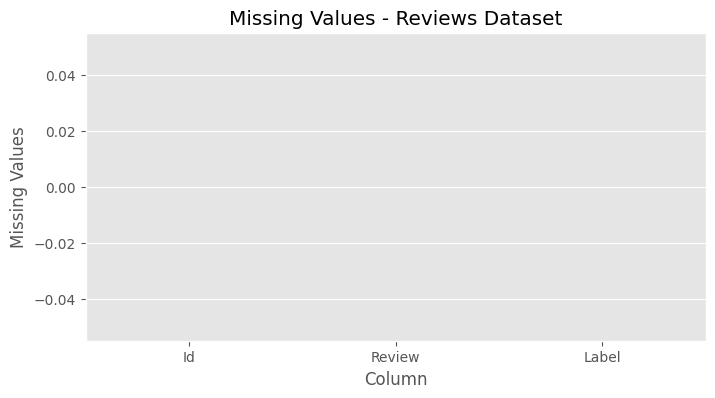

In [4]:
def missing_values(df,name):
    missing=df.isnull().sum()
    report=pd.DataFrame({
        "Column":missing.index,
        "Missing Values":missing.values,
        "Percentage":((missing/len(df))*100).round(2).values
    })
    display(report)
    plt.figure(figsize=(8,4))
    sns.barplot(data=report,x="Column",y="Missing Values")
    plt.title(f"Missing Values - {name}")
    plt.show()

missing_values(reviews,"Reviews Dataset")

## Duplicate Analysis

In [5]:
def duplicate_analysis(df,name):
    print("="*70)
    print(name)
    print("="*70)
    print("Duplicate Rows:",df.duplicated().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())

duplicate_analysis(reviews,"Reviews Dataset")

Reviews Dataset
Duplicate Rows: 0
Duplicate Reviews: 6980


## Label Distribution

,Count,Percentage
Label,,
1,2469,2.31
2,2251,2.10
3,5071,4.74
4,18054,16.87
5,79173,73.98


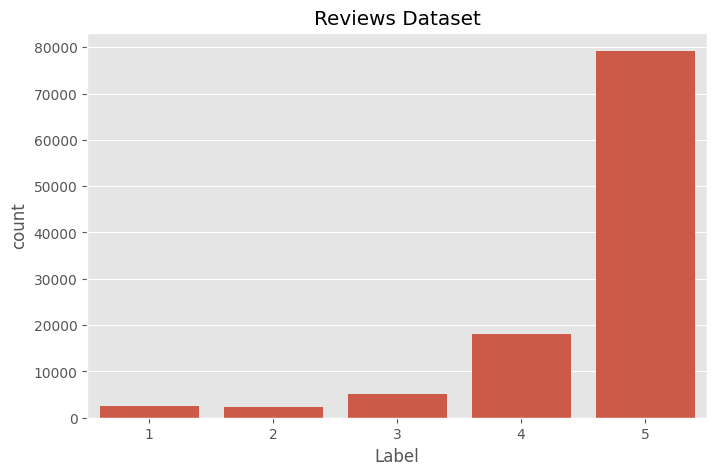

In [6]:
def label_distribution(df,name):
    summary=pd.DataFrame({
        "Count":df["Label"].value_counts().sort_index(),
        "Percentage":(df["Label"].value_counts(normalize=True).sort_index()*100).round(2)
    })
    display(summary)
    plt.figure(figsize=(8,5))
    sns.countplot(data=df,x="Label")
    plt.title(name)
    plt.show()

label_distribution(reviews,"Reviews Dataset")

## Review Length Analysis

,Review Length
count,107018.000000
mean,146.798978
std,188.874884
min,1.000000
25%,44.000000
50%,90.000000
75%,180.000000
max,7766.000000


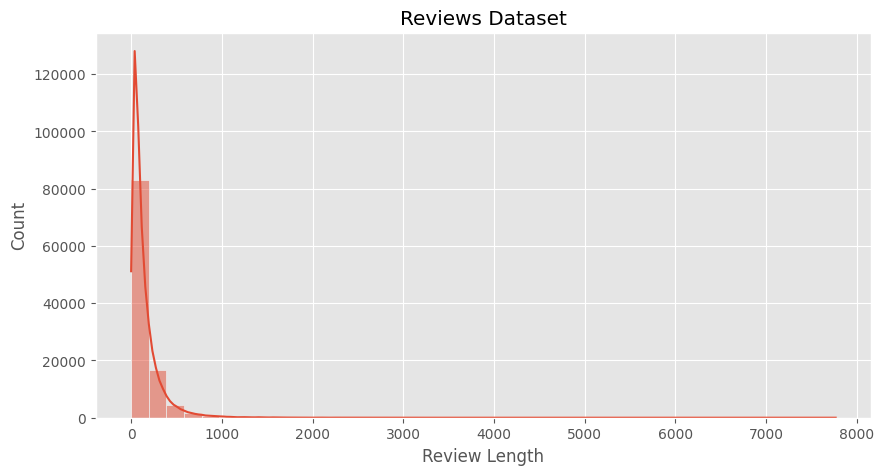

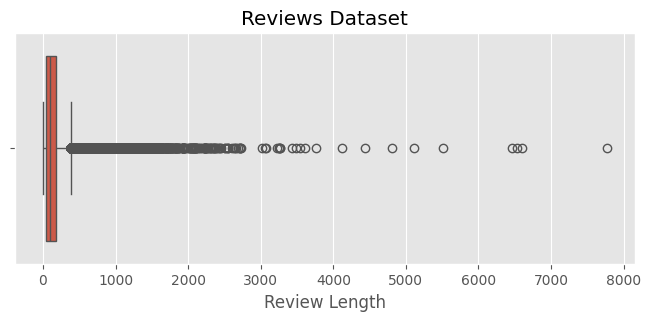

In [7]:
def review_length(df,name):
    df["Review Length"]=df["Review"].astype(str).apply(len)
    display(df["Review Length"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Review Length"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Review Length"])
    plt.title(name)
    plt.show()

review_length(reviews,"Reviews Dataset")

## Word Count Analysis

,Word Count
count,107018.000000
mean,24.871134
std,32.427376
min,1.000000
25%,7.000000
50%,15.000000
75%,31.000000
max,1338.000000


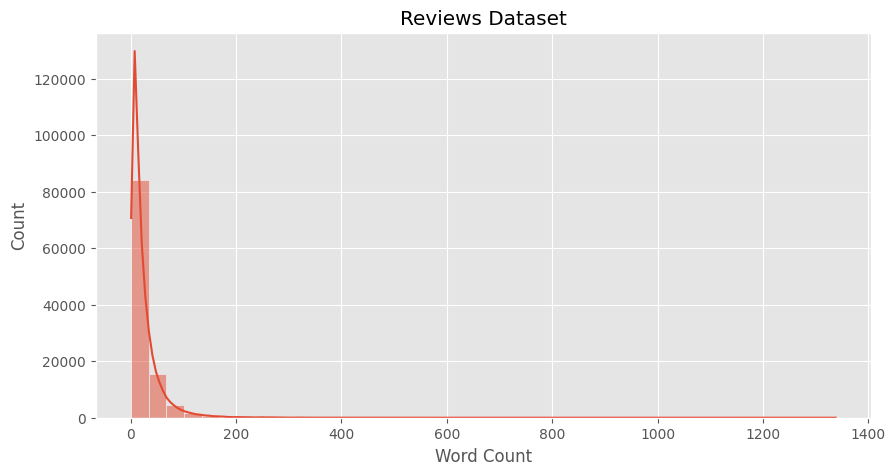

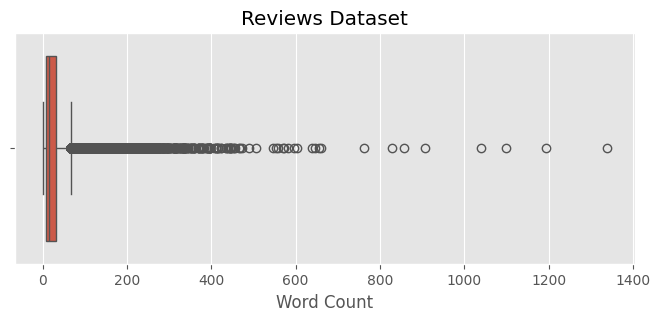

In [8]:
def word_count(df,name):
    df["Word Count"]=df["Review"].astype(str).apply(lambda x: len(x.split()))
    display(df["Word Count"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Word Count"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Word Count"])
    plt.title(name)
    plt.show()

word_count(reviews,"Reviews Dataset")

## Dataset Summary

In [9]:
def dataset_summary(df,name):
    print("="*80)
    print(name)
    print("="*80)
    print("Total Reviews:",len(df))
    print("Missing Reviews:",df["Review"].isnull().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())
    print("Average Review Length:",round(df["Review Length"].mean(),2))
    print("Average Word Count:",round(df["Word Count"].mean(),2))

dataset_summary(reviews,"Reviews Dataset")

Reviews Dataset
Total Reviews: 107018
Missing Reviews: 0
Duplicate Reviews: 6980
Average Review Length: 146.8
Average Word Count: 24.87


---
# Module_1B_Advanced_EDA


# Module 1B: Advanced Exploratory Data Analysis (EDA)

This notebook performs advanced NLP-oriented EDA on both datasets.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")


## Word Cloud

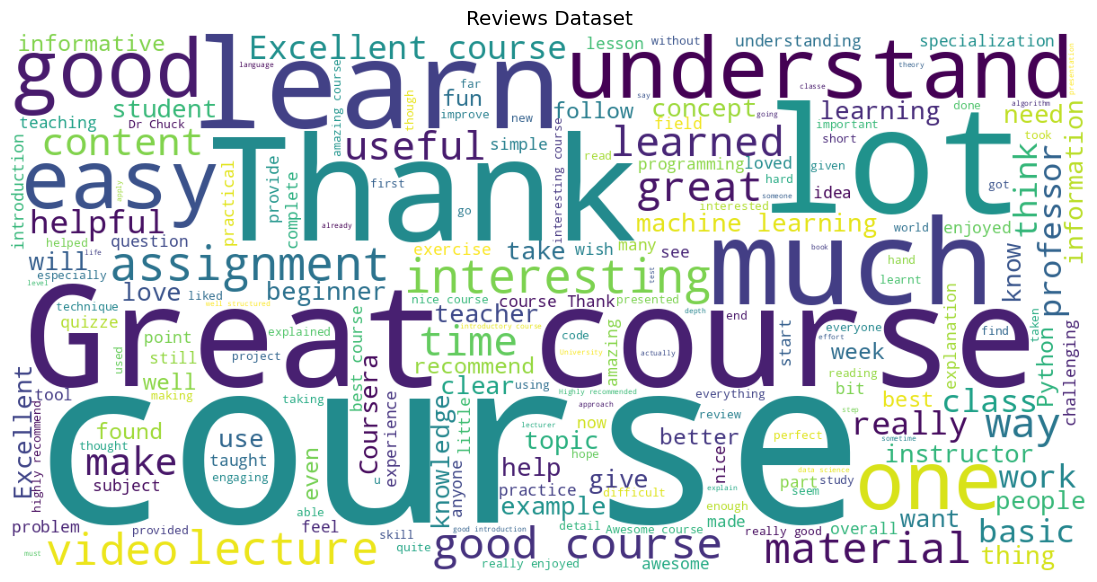

In [11]:
def plot_wordcloud(df,title):
    text=" ".join(df["Review"].fillna("").astype(str))
    wc=WordCloud(width=1200,height=600,background_color="white").generate(text)
    plt.figure(figsize=(14,7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(reviews,"Reviews Dataset")

## Top 20 Words

,Word,Count
0,the,130856
1,and,91883
2,to,86128
3,course,84641
4,i,71271
5,a,65794
6,of,55335
7,this,44184
8,is,42724
9,it,42654


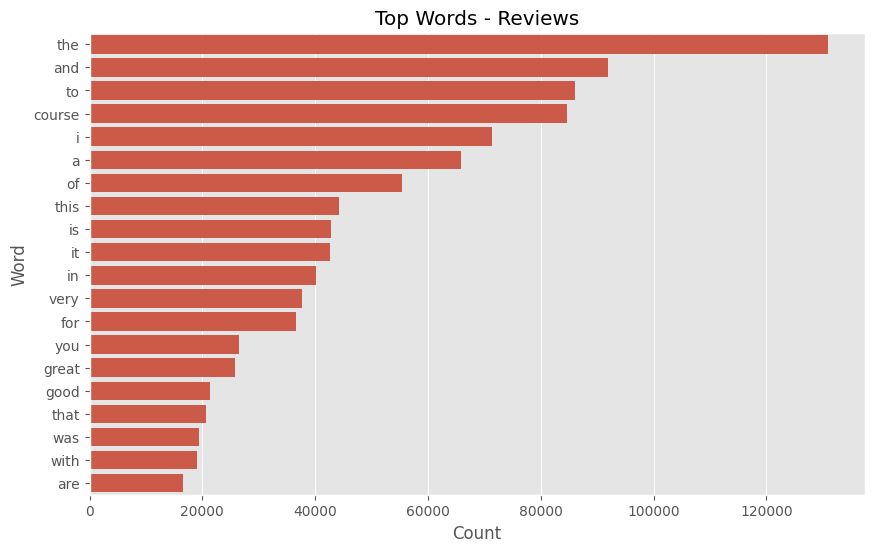

In [12]:
def top_words(df,title):
    words=re.findall(r"\b\w+\b"," ".join(df["Review"].fillna("").astype(str)).lower())
    common=Counter(words).most_common(20)
    top=pd.DataFrame(common,columns=["Word","Count"])
    display(top)
    plt.figure(figsize=(10,6))
    sns.barplot(data=top,x="Count",y="Word")
    plt.title(title)
    plt.show()

top_words(reviews,"Top Words - Reviews")


## Top 20 Bigrams

,Bigram,Count
201962,great course,9416
196710,good course,4987
155367,excellent course,3920
291099,machine learning,3522
266661,learned lot,2246
97387,course really,1988
135999,easy understand,1986
95499,course great,1848
392032,recommend course,1825
95464,course good,1472


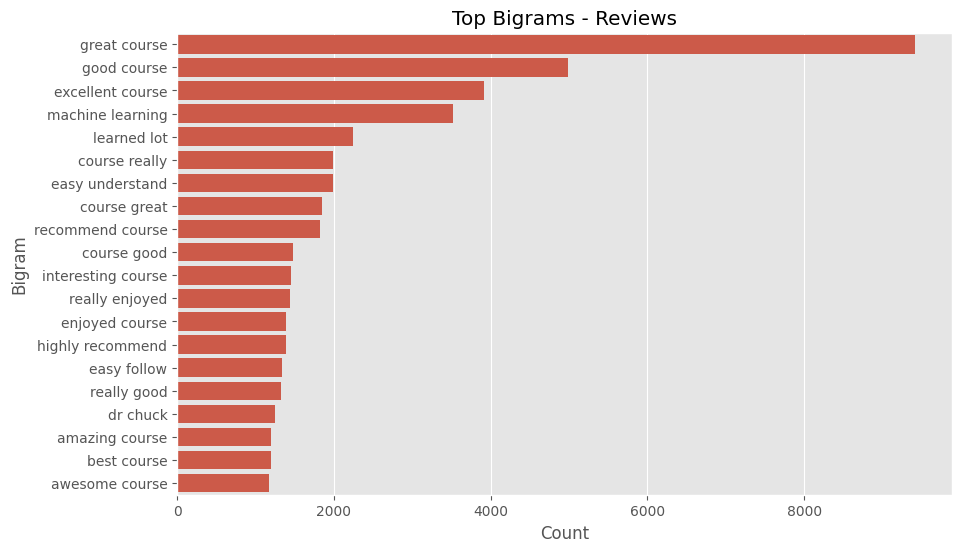

In [13]:
def top_bigrams(df,title):
    vec=CountVectorizer(ngram_range=(2,2),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    big=pd.DataFrame({"Bigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(big)
    plt.figure(figsize=(10,6))
    sns.barplot(data=big,x="Count",y="Bigram")
    plt.title(title)
    plt.show()

top_bigrams(reviews,"Top Bigrams - Reviews")


## Top 20 Trigrams

,Trigram,Count
693511,really enjoyed course,600
395618,highly recommend course,516
167313,course learned lot,475
694455,really good course,372
365908,great course great,368
445434,introduction machine learning,320
482442,learned lot course,297
353856,good introductory course,286
169603,course machine learning,271
369687,great introductory course,252


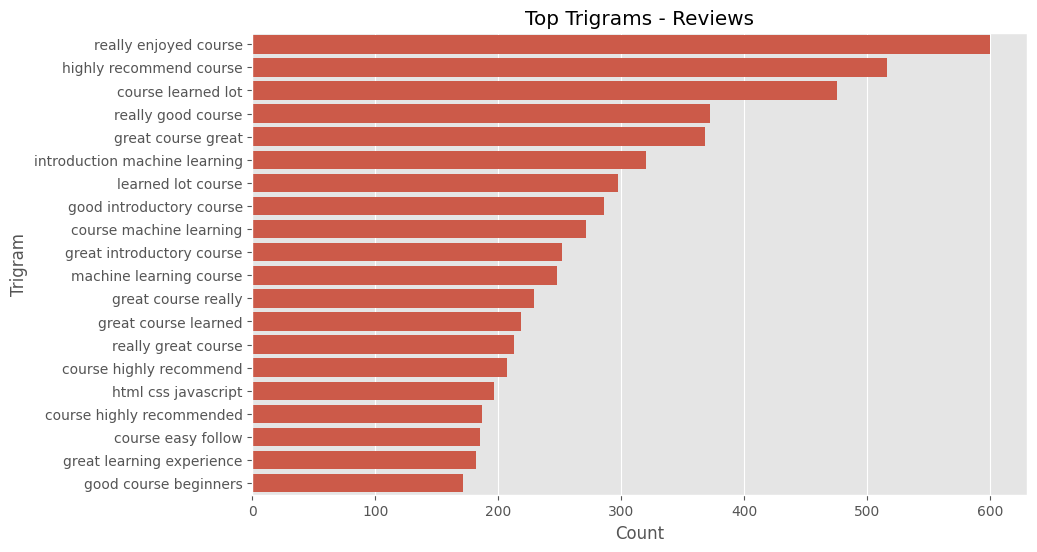

In [14]:
def top_trigrams(df,title):
    vec=CountVectorizer(ngram_range=(3,3),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    tri=pd.DataFrame({"Trigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(tri)
    plt.figure(figsize=(10,6))
    sns.barplot(data=tri,x="Count",y="Trigram")
    plt.title(title)
    plt.show()

top_trigrams(reviews,"Top Trigrams - Reviews")


## Review Length vs Rating

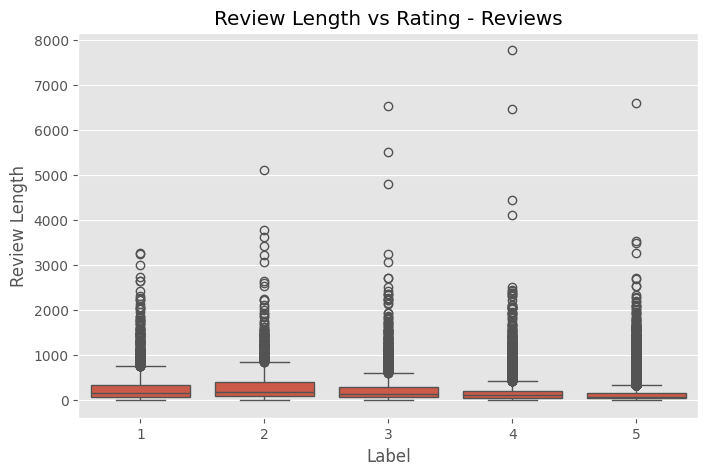

In [15]:
for df,name in [(reviews,"Reviews")]:
    df["Review Length"]=df["Review"].fillna("").astype(str).apply(len)
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df,x="Label",y="Review Length")
    plt.title(f"Review Length vs Rating - {name}")
    plt.show()


## Export EDA Report

In [16]:
def eda_report(df,name):
    report=pd.DataFrame({
        "Metric":[
            "Rows","Columns","Missing Reviews","Duplicate Reviews","Average Review Length"
        ],
        "Value":[
            len(df),
            len(df.columns),
            df["Review"].isnull().sum(),
            df.duplicated(subset=["Review"]).sum(),
            df["Review"].fillna("").astype(str).apply(len).mean()
        ]
    })
    report.to_csv(f"{name}_EDA_Report.csv",index=False)
    display(report)

eda_report(reviews,"Reviews")
print("EDA reports saved.")


,Metric,Value
0,Rows,107018.000000
1,Columns,4.000000
2,Missing Reviews,0.000000
3,Duplicate Reviews,6980.000000
4,Average Review Length,146.798978


EDA reports saved.


---
# Module_2_Preprocessing


# Module 2: Data Preprocessing

This notebook cleans both datasets and prepares them for Tiny Bert.

In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")
print("Datasets Loaded")

Datasets Loaded


## Save Original Statistics

In [18]:
def dataset_statistics(df):
    return {
        "Total Rows":len(df),
        "Missing Reviews":df["Review"].isnull().sum(),
        "Duplicate Reviews":df.duplicated(subset=["Review"]).sum(),
        "Empty Reviews":(df["Review"].fillna("").str.strip()=="").sum()
    }

reviews_before=dataset_statistics(reviews)

## Text Cleaning Function

In [19]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text=str(text)

    text=re.sub(r"<.*?>"," ",text)
    text=re.sub(r"http\S+|www\S+"," ",text)
    text=re.sub(r"\S+@\S+"," ",text)
    text=re.sub(r"\s+"," ",text)

    return text.strip()


## Apply Preprocessing

In [20]:
def preprocess(df):

    df = df.copy()

    # Clean text
    df["Review"] = df["Review"].apply(clean_text)

    # Remove empty reviews
    df = df[df["Review"].str.strip() != ""]

    # Remove reviews with less than 2 words
    df = df[df["Review"].apply(lambda x: len(str(x).split()) >= 2)]

    # Remove duplicate reviews
    df = df.drop_duplicates(subset=["Review"])

    # Remove missing values
    df = df.dropna(subset=["Review"])

    # Ensure string datatype
    df["Review"] = df["Review"].astype(str)

    # Convert ratings to sentiment labels
    df["Label"] = df["Label"].apply(
        lambda x: 0 if x in [1, 2]
        else 1 if x == 3
        else 2
    )

    df.reset_index(drop=True, inplace=True)

    return df


reviews_clean = preprocess(reviews)

print("Preprocessing Completed")

Preprocessing Completed


## Save Cleaned Datasets

In [21]:
reviews_clean.to_csv("reviews_cleaned.csv",index=False)

print("Cleaned datasets saved.")

Cleaned datasets saved.


In [22]:
print("Label Distribution")
print(reviews_clean["Label"].value_counts().sort_index())

print("\nMeaning:")
print("0 = Negative (Ratings 1 & 2)")
print("1 = Neutral (Rating 3)")
print("2 = Positive (Ratings 4 & 5)")

Label Distribution
Label
0     4596
1     4978
2    90276
Name: count, dtype: int64

Meaning:
0 = Negative (Ratings 1 & 2)
1 = Neutral (Rating 3)
2 = Positive (Ratings 4 & 5)


## Preprocessing Report

In [23]:
reviews_after=dataset_statistics(reviews_clean)

def report(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    print(title)

    display(df)

    return df

rep1=report(reviews_before,reviews_after,"Reviews Dataset")

rep1.to_csv("Reviews_Preprocessing_Report.csv")

Reviews Dataset


,Before,After
Total Rows,107018,99850
Missing Reviews,0,0
Duplicate Reviews,6980,0
Empty Reviews,0,0


## Before vs After Visualization

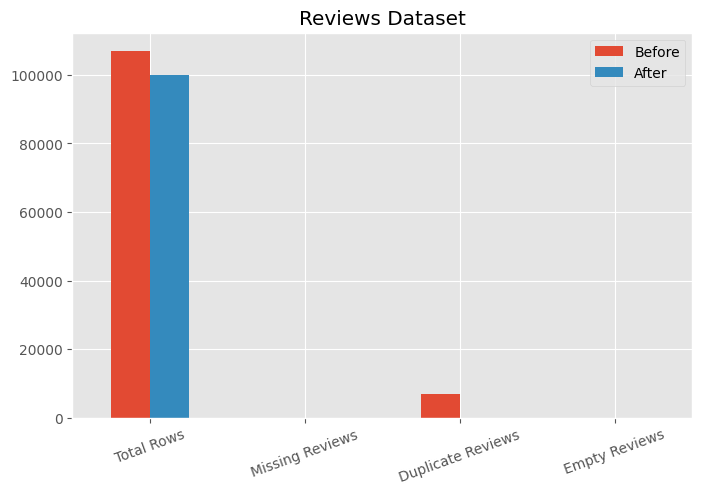

In [24]:
def compare(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    df.plot(kind="bar",figsize=(8,5))
    plt.title(title)
    plt.xticks(rotation=20)
    plt.show()

compare(reviews_before,reviews_after,"Reviews Dataset")


## Final Verification

In [25]:
print("="*60)
print("Reviews Dataset")
print(reviews_clean.shape)
display(reviews_clean.head())

print("\nModule 2 Completed Successfully.")

Reviews Dataset
(99850, 3)


,Id,Review,Label
0,0,good and interesting,2
1,1,"This class is very helpful to me. Currently, I...",2
2,2,like!Prof and TAs are helpful and the discussi...,2
3,3,Easy to follow and includes a lot basic and im...,2
4,4,Really nice teacher!I could got the point eazl...,2



Module 2 Completed Successfully.


# TINY BERT

In [26]:
!pip install -q transformers datasets accelerate evaluate scikit-learn lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00


In [27]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
print(reviews_clean.shape)
print(reviews_clean.head())
print(reviews_clean.columns)

(99850, 3)
   Id                                             Review  Label
0   0                               good and interesting      2
1   1  This class is very helpful to me. Currently, I...      2
2   2  like!Prof and TAs are helpful and the discussi...      2
3   3  Easy to follow and includes a lot basic and im...      2
4   4  Really nice teacher!I could got the point eazl...      2
Index(['Id', 'Review', 'Label'], dtype='object')


In [29]:
# Keep only the columns required for TinyBERT
reviews_tinybert = reviews_clean[["Review", "Label"]].copy()

print(reviews_tinybert.shape)
print(reviews_tinybert.head())

(99850, 2)
                                              Review  Label
0                               good and interesting      2
1  This class is very helpful to me. Currently, I...      2
2  like!Prof and TAs are helpful and the discussi...      2
3  Easy to follow and includes a lot basic and im...      2
4  Really nice teacher!I could got the point eazl...      2


In [30]:
print(reviews_tinybert["Label"].value_counts().sort_index())

Label
0     4596
1     4978
2    90276
Name: count, dtype: int64


In [31]:
train_df, test_df = train_test_split(
    reviews_tinybert,
    test_size=0.20,
    random_state=42,
    stratify=reviews_tinybert["Label"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 79880
Testing samples: 19970


In [32]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['Review', 'Label'],
    num_rows: 79880
})
Dataset({
    features: ['Review', 'Label'],
    num_rows: 19970
})


In [33]:
MODEL_NAME = "huawei-noah/TinyBERT_General_4L_312D"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [34]:
def tokenize_function(examples):
    return tokenizer(
        examples["Review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [35]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/79880 [00:00<?, ? examples/s]

Map:   0%|          | 0/19970 [00:00<?, ? examples/s]

In [36]:
print(train_dataset[0])

{'Review': 'Professor Ng does a great job of breaking down the fundamentals of machine learning. This has been a great starting point for me', 'Label': 2, 'input_ids': [101, 2934, 12835, 2515, 1037, 2307, 3105, 1997, 4911, 2091, 1996, 8050, 2015, 1997, 3698, 4083, 1012, 2023, 2038, 2042, 1037, 2307, 3225, 2391, 2005, 2033, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [37]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    label2id={
        "Negative": 0,
        "Neutral": 1,
        "Positive": 2
    }
)

print("TinyBERT model loaded successfully!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 62.7MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/arch

TinyBERT model loaded successfully!


In [38]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [39]:
train_dataset = train_dataset.rename_column("Label", "labels")
test_dataset = test_dataset.rename_column("Label", "labels")

print(train_dataset.column_names)
print(test_dataset.column_names)

['Review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']
['Review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [40]:
train_dataset = train_dataset.remove_columns(["Review"])
test_dataset = test_dataset.remove_columns(["Review"])

print(train_dataset.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [41]:
print("Training dataset:")
print(train_dataset)

print("\nTesting dataset:")
print(test_dataset)

print("\nTraining columns:")
print(train_dataset.column_names)

Training dataset:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 79880
})

Testing dataset:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 19970
})

Training columns:
['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [46]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [48]:
training_args = TrainingArguments(
    output_dir="./tinybert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=25,

    report_to="none"
)

In [49]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [50]:
train_dataset.reset_format()
test_dataset.reset_format()

print("Dataset format reset successfully!")
print(train_dataset.format)

Dataset format reset successfully!
{'type': None, 'format_kwargs': {}, 'columns': ['labels', 'input_ids', 'token_type_ids', 'attention_mask'], 'output_all_columns': False}


In [51]:
print(train_dataset[0])

{'labels': 2, 'input_ids': [101, 2934, 12835, 2515, 1037, 2307, 3105, 1997, 4911, 2091, 1996, 8050, 2015, 1997, 3698, 4083, 1012, 2023, 2038, 2042, 1037, 2307, 3225, 2391, 2005, 2033, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 

In [52]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer recreated successfully!")

Trainer recreated successfully!


In [53]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.222215,0.187849,0.931647,0.917487,0.931647,0.922875
2,0.182340,0.194201,0.934251,0.922067,0.934251,0.925771
3,0.212883,0.189415,0.930496,0.929796,0.930496,0.930100
4,0.169344,0.207143,0.935053,0.927411,0.935053,0.930673


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
evaluation_results = trainer.evaluate()

print("\nTinyBERT Evaluation Results:")

for key, value in evaluation_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.169344,0.207143,4,0.935053,0.927411,0.935053,0.930673



TinyBERT Evaluation Results:
eval_loss: 0.2071
eval_accuracy: 0.9351
eval_precision: 0.9274
eval_recall: 0.9351
eval_f1: 0.9307


In [55]:
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = predictions.label_ids

print("Predicted labels:")
print(predicted_labels[:20])

print("\nTrue labels:")
print(true_labels[:20])

Predicted labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

True labels:
[2 2 2 2 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2]


In [56]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.71      0.67      0.69       919
     Neutral       0.45      0.33      0.38       996
    Positive       0.97      0.98      0.97     18055

    accuracy                           0.94     19970
   macro avg       0.71      0.66      0.68     19970
weighted avg       0.93      0.94      0.93     19970



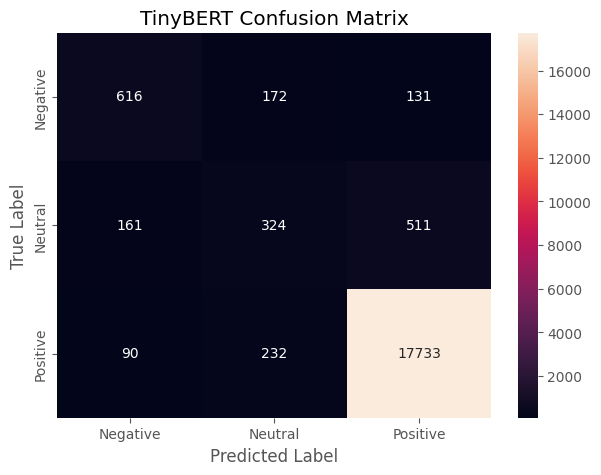

In [57]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TinyBERT Confusion Matrix")

plt.show()

In [58]:
MODEL_SAVE_PATH = "./tinybert_sentiment_model"

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print("TinyBERT model saved successfully!")
print("Saved at:", MODEL_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TinyBERT model saved successfully!
Saved at: ./tinybert_sentiment_model


In [59]:
import os

print(os.listdir(MODEL_SAVE_PATH))

['tokenizer_config.json', 'model.safetensors', 'training_args.bin', 'config.json', 'tokenizer.json']


# LIME

In [60]:
from lime.lime_text import LimeTextExplainer

In [61]:
explainer = LimeTextExplainer(
    class_names=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [62]:
model.eval()

print("TinyBERT is now in evaluation mode.")

TinyBERT is now in evaluation mode.


In [63]:
def predict_proba(texts):
    """
    Takes a list of text reviews and returns
    TinyBERT class probabilities.
    """

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move tensors to the same device as the model
    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    return probabilities.cpu().numpy()

In [64]:
test_review = input("Enter your review: ")

prediction_probabilities = predict_proba([test_review])

print("\nPrediction probabilities:")
print(prediction_probabilities)

Enter your review: The course was really great and the instructor helped a lot with my doubts

Prediction probabilities:
[[1.4575594e-04 1.1845654e-03 9.9866974e-01]]


In [65]:
label_names = [
    "Negative",
    "Neutral",
    "Positive"
]

predicted_class = np.argmax(
    prediction_probabilities[0]
)

confidence = prediction_probabilities[0][predicted_class]

print("\nReview:")
print(test_review)

print("\nPredicted Sentiment:", label_names[predicted_class])
print("Confidence:", f"{confidence * 100:.2f}%")


Review:
The course was really great and the instructor helped a lot with my doubts

Predicted Sentiment: Positive
Confidence: 99.87%


In [66]:
# Generate LIME explanation for all 3 sentiment classes

explanation = explainer.explain_instance(
    test_review,
    predict_proba,
    labels=[0, 1, 2],
    num_features=10,
    num_samples=1000
)

print("LIME explanation generated successfully!")

LIME explanation generated successfully!


In [67]:
print("\nLIME Explanation:")

for word, weight in explanation.as_list():
    print(f"{word}: {weight:.4f}")


LIME Explanation:
great: -0.0590
helped: -0.0474
doubts: 0.0406
my: -0.0231
was: 0.0145
really: -0.0122
lot: -0.0114
course: -0.0071
a: 0.0066
with: 0.0039


In [68]:
# Display LIME visualization

explanation.show_in_notebook(
    text=True,
    predict_proba=True
)

In [69]:
print("\nPredicted Class:", label_names[predicted_class])

print("\nWords influencing the prediction:")

for word, weight in explanation.as_list(
    label=predicted_class
):
    print(f"{word}: {weight:.4f}")


Predicted Class: Positive

Words influencing the prediction:
great: 0.1291
helped: 0.1120
doubts: -0.0875
my: 0.0552
instructor: -0.0290
was: -0.0270
lot: 0.0235
really: 0.0208
course: 0.0137
a: -0.0136


In [70]:
def analyze_review():

    # Get user review
    review = input("\nEnter your review: ")

    # TinyBERT prediction
    probabilities = predict_proba([review])

    predicted_class = int(np.argmax(probabilities[0]))
    confidence = probabilities[0][predicted_class]

    # Display prediction
    print("\n" + "=" * 50)
    print("REVIEW")
    print("=" * 50)
    print(review)

    print("\n" + "=" * 50)
    print("PREDICTION")
    print("=" * 50)
    print("Sentiment:", label_names[predicted_class])
    print("Confidence:", f"{confidence * 100:.2f}%")

    # Generate LIME explanation for all 3 classes
    explanation = explainer.explain_instance(
        review,
        predict_proba,
        labels=[0, 1, 2],
        num_features=10,
        num_samples=1000
    )

    print("\n" + "=" * 50)
    print("LIME EXPLANATION")
    print("=" * 50)

    # Use Python int instead of numpy int
    for word, weight in explanation.as_list(
        label=predicted_class
    ):
        direction = (
            "→ supports prediction"
            if weight > 0
            else "→ opposes prediction"
        )

        print(
            f"{word:20s} {weight:+.4f} {direction}"
        )

    # Display LIME visualization
    explanation.show_in_notebook(
        text=True,
        predict_proba=True
    )

    return explanation

In [71]:
explanation = analyze_review()


Enter your review: The course was not nice, I didn't liked the way instructor taught

REVIEW
The course was not nice, I didn't liked the way instructor taught

PREDICTION
Sentiment: Negative
Confidence: 94.75%

LIME EXPLANATION
not                  +0.5732 → supports prediction
didn                 +0.2417 → supports prediction
nice                 -0.2118 → opposes prediction
t                    +0.1990 → supports prediction
course               +0.0707 → supports prediction
liked                -0.0439 → opposes prediction
was                  +0.0284 → supports prediction
I                    -0.0256 → opposes prediction
The                  -0.0211 → opposes prediction
instructor           +0.0185 → supports prediction
